# Causal-prior FasterRisk on synthetic linear-Gaussian DAGs

Modified FasterRisk with a soft causal-prior penalty, evaluated on synthetic data where the true support $S^*$ and the causal partition are known. For each cell (combination of $p$, $n$, $k^*$, $p_\mathrm{edge}$), 20 seeds, $K = 2 k^*$, $\mu$ scanned across a log grid relative to the median data gradient.

Five $q$ sources compared: GES (causal discovery via R-pcalg), bootstrap-$L_1$ (predictive stability), uniform (no preference; mathematically equivalent to vanilla FR), adversarial (q on confounders only), and oracle (hard $S^*$ membership, dropped from headlines as a non-operational reference). PC was tested; Fisher-Z on dense Gaussian DAGs returns near-noise q and is omitted.

**Recovery metrics.** $S^*$ is the set of *direct parents* of $Y$ — the minimal sufficient predictor set (given $S^*$, $Y$ is independent of the indirect causes, so $S^*$ is the strong, non-redundant set you want in a scorecard). We score the fitted FR support three ways:
- `S_precision` (**primary**) — fraction of picks hitting the direct parents $S^*$. Recovering the minimal/strong causal set is the primary goal; this separates causal $q$ from predictive $q$ at every density.
- `correlate_inclusion` (**co-headline**, lower is better) — fraction of picks that are *genuinely non-causal* correlates (descendants of causes, common-effect structure). Isolates confounder avoidance.
- `causal_precision` (**diagnostic**) — fraction that are *any* cause (direct or indirect, i.e. ancestors of $Y$). Saturates at high density (almost every node is a cause), which is exactly what shows that the high-$p_\mathrm{edge}$ `S_precision` gap is direct-vs-indirect discrimination, not confounder avoidance.

The cause-aware columns are derived from the stored supports by `loading.add_causal_metrics` (no refit).

The noise sweep ($\sigma_\mathrm{noise} \in \{0.5, 1.0, 2.0\}$) only generated extra cells at the anchor. The non-noise sweep slices below filter to $\sigma_\mathrm{noise}=1.0$ so the anchor point in each axis doesn't silently triple its sample size; `noise_sweep` / `noise_cv` keep all three for the SNR panel.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[2]))

from src.causal_prior.loading import load_recovery_csvs
from src.causal_prior import visualization as viz

ROOT = Path.cwd().parents[2]
recovery = load_recovery_csvs(ROOT / 'results/causal_prior/synthetic/recovery_p30_headline')

In [2]:
recovery = recovery[~recovery['q_source'].str.startswith('pc')]
recovery = recovery[recovery['q_source'] != 'oracle']

default_noise = recovery['noise_scale'] == 1.0
pe_sweep    = recovery[default_noise].query('p == 30 and n == 300 and k_star == 5')        # vary p_edge
n_sweep     = recovery[default_noise].query('p == 30 and k_star == 5 and p_edge == 0.2')   # vary n
p_sweep     = recovery[default_noise].query('n == 300 and k_star == 5 and p_edge == 0.2')  # vary p
k_sweep     = recovery[default_noise].query('p == 30 and n == 300 and p_edge == 0.2')      # vary k_star
noise_sweep = recovery.query('p == 30 and n == 300 and k_star == 5 and p_edge == 0.2')     # vary noise

In [3]:
cv = load_recovery_csvs(ROOT / 'results/causal_prior/synthetic/recovery_p30_headline_cv')
cv = cv[~cv['q_source'].str.startswith('pc')]
cv = cv[cv['q_source'] != 'oracle']

default_noise = cv['noise_scale'] == 1.0
pe_cv    = cv[default_noise].query('p == 30 and n == 300 and k_star == 5')        # vary p_edge
n_cv     = cv[default_noise].query('p == 30 and k_star == 5 and p_edge == 0.2')   # vary n
p_cv     = cv[default_noise].query('n == 300 and k_star == 5 and p_edge == 0.2')  # vary p
k_cv     = cv[default_noise].query('p == 30 and n == 300 and p_edge == 0.2')      # vary k_star
noise_cv = cv.query('p == 30 and n == 300 and k_star == 5 and p_edge == 0.2')     # vary noise

## Headline: causal $q$ recovers the minimal causal set, and avoids non-causal correlates

For each cell and $q$ source, pick $\hat{\mu}$ by 5-fold CV on log-loss, refit on full data, evaluate against the known causal partition. Anchor $p=30, n=300, k^*=5$; vanilla ($=$ uniform $q$) is the no-prior reference. Two complementary claims, two metrics.

**1. Minimal causal recovery (`S_precision`, primary panel below).** Fraction of picks that are the *direct parents* $S^*$ of $Y$ — the minimal sufficient predictor set. GES beats predictive-$L_1$ beats vanilla at **every** density, and the gap *grows* with $p_\mathrm{edge}$: GES$-$vanilla rises from +0.14 ($p_\mathrm{edge}=0.1$) to ~+0.20–0.29 ($p_\mathrm{edge}\geq 0.3$), with GES (0.32) $>$ $L_1$ (0.18) $>$ vanilla (0.12) at $p_\mathrm{edge}=0.7$. This is the causal-vs-predictive separation the method claims.

**2. Confounder avoidance (`correlate_inclusion`, second panel, lower is better).** Fraction of picks that are *genuinely non-causal* correlates. GES picks ~0.07–0.09 fewer spurious features than vanilla at $p_\mathrm{edge}=0.1$–$0.2$ (paired $t\approx 2$–$4$), converging to ~0 by $p_\mathrm{edge}\geq 0.3$ — not because the prior stops working but because the correlate set empties out (at $p_\mathrm{edge}=0.7$ only ~5 of 30 features are non-causal; ~20 are indirect causes).

**What separates the two — and why the high-density gain is *not* confounder avoidance.** At high density `S_precision` keeps separating sources while `causal_precision` (any-cause; diagnostic panel) saturates near 1.0, because almost every node is a cause. So the high-$p_\mathrm{edge}$ `S_precision` gain is GES preferring *direct/strong* causes over *indirect* ones (a minimality win), not avoidance of non-causal confounders. The earlier draft narrated that gap as 'the prior beats confounding' — wrong word: genuine confounder avoidance is the low-density `correlate_inclusion` effect. Both claims are real; they answer different questions.

<Axes: title={'center': '$p_{\\mathrm{edge}}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$p_{\\mathrm{edge}}$', ylabel='S precision'>

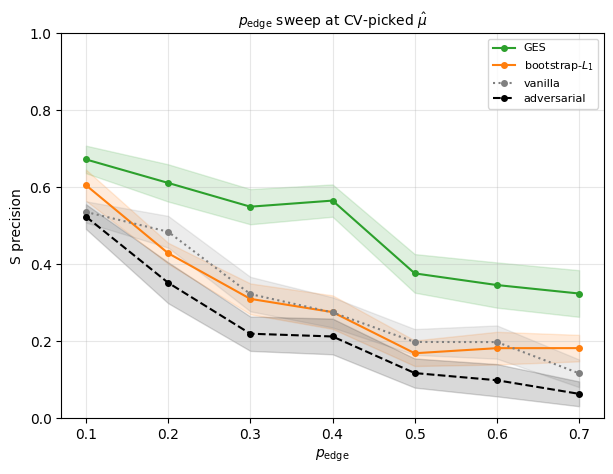

In [4]:
viz.plot_recovery_cv_vs_axis(pe_cv, axis_col='p_edge', metric='S_precision')

### Confounder-avoidance panel (`correlate_inclusion`, lower is better)

Same headline cell, scored by the fraction of selections that are genuinely non-causal correlates. GES sits below vanilla at $p_\mathrm{edge}=0.1$–$0.2$ (~0.07–0.09 fewer spurious picks) and converges with all sources once the correlate set shrinks at high density — the low-density component of claim 2.

<Axes: title={'center': '$p_{\\mathrm{edge}}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$p_{\\mathrm{edge}}$', ylabel='correlate inclusion'>

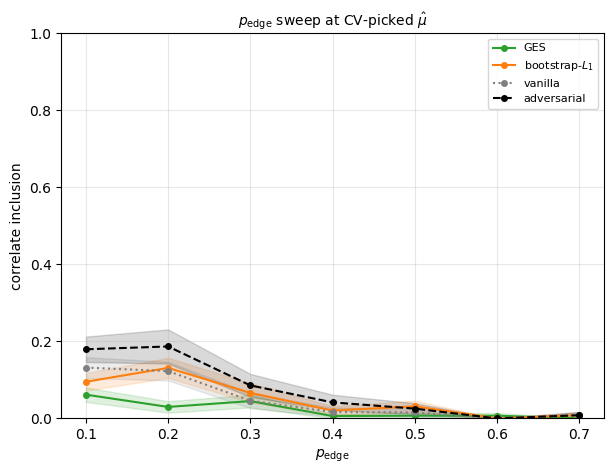

In [5]:
viz.plot_recovery_cv_vs_axis(pe_cv, axis_col='p_edge', metric='correlate_inclusion')

### Diagnostic: any-cause precision (`causal_precision`)

Fraction of picks that are *any* true cause (direct or indirect). It tracks `S_precision` at low density but **saturates near 1.0 from $p_\mathrm{edge}\geq 0.3$**, because at high density almost every node is an ancestor of $Y$. That saturation is the proof that the high-density `S_precision` gap is direct-vs-indirect cause discrimination, not confounder avoidance — there are essentially no non-causal features left to differentiate on.

<Axes: title={'center': '$p_{\\mathrm{edge}}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$p_{\\mathrm{edge}}$', ylabel='causal precision'>

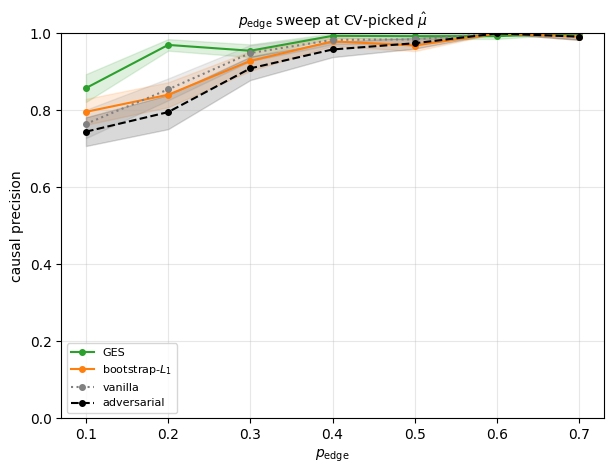

In [6]:
viz.plot_recovery_cv_vs_axis(pe_cv, axis_col='p_edge', metric='causal_precision')

## Diagnostic: $\hat{\mu}_\mathrm{CV}$ vs $p_\mathrm{edge}$

How the CV-picked strength moves with confounding density. Open white markers flag cells where CV picked $\hat{\mu}=0$ ($\geq 50\%$ of seeds collapsed to vanilla). GES stays non-zero across all $p_\mathrm{edge}$; vanilla and adversarial sit at the floor as expected. The precision gap survives because $\hat{\mu}$ lands in the $\mu$-flat plateau ([10^{-2}, 10] in stage-1 grid).

<Axes: title={'center': 'CV-picked $\\mu$ vs $p_{\\mathrm{edge}}$'}, xlabel='$p_{\\mathrm{edge}}$', ylabel='$\\hat{\\mu}_{\\mathrm{rel}}$ (CV)'>

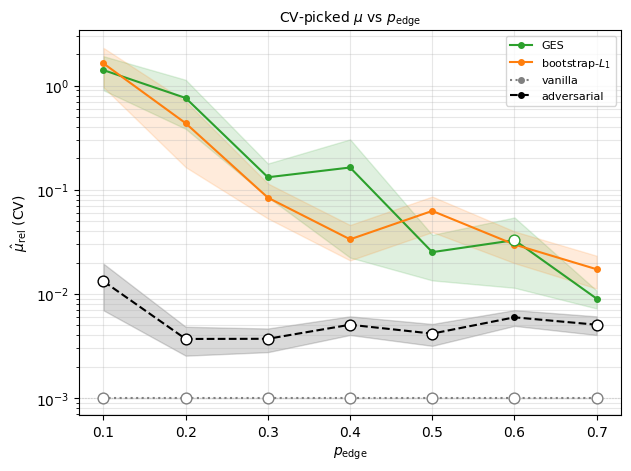

In [7]:
viz.plot_mu_star_vs_axis(pe_cv, axis_col='p_edge')

## Effect peaks at moderate $n$, washes out when data is abundant

$n$ sweep at $p=30, k^*=5, p_\mathrm{edge}=0.2$, `S_precision` at CV-picked $\hat{\mu}$ (10 seeds, noisier than the 20-seed headline). GES$-$vanilla rises from +0.08 ($n=75$) to +0.13–0.17 around $n=150$–$300$, then collapses to ~0 by $n=500$. At very small $n$ discovery is too noisy to help; at large $n$ the data alone recovers $S^*$ and the prior adds nothing. The prior earns its keep in the data-limited middle — where $n=164$ TB sits. (`causal_precision` tracks the same shape: +0.09–0.12 in the middle, ~0 by $n=500$.)

<Axes: title={'center': '$n$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$n$', ylabel='S precision'>

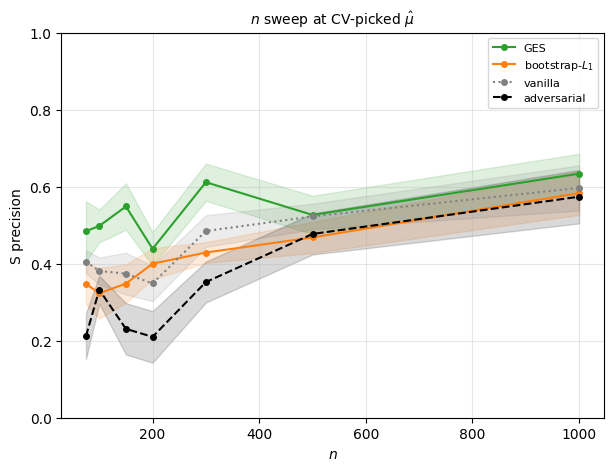

In [8]:
viz.plot_recovery_cv_vs_axis(n_cv, axis_col='n')

## Effect grows with feature count — but read the diagnostic at $p=50$

$p$ sweep at $n=300, k^*=5, p_\mathrm{edge}=0.2$, `S_precision`. GES$-$vanilla is ~0 at $p=10$, +0.13 at $p=30$, +0.34 at $p=50$: more candidate features, more room for the prior to steer the $K$ slots toward $S^*$. **Caveat:** at $p=50$ `causal_precision` says the gap is only +0.01 — so most of the $p=50$ `S_precision` gain is GES preferring *direct* over *indirect* causes (a denser graph has more indirect causes crowding the support), not extra non-causal-correlate avoidance. Read $p=50$ as a minimality win, not a confounding win.

<Axes: title={'center': '$p$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$p$', ylabel='S precision'>

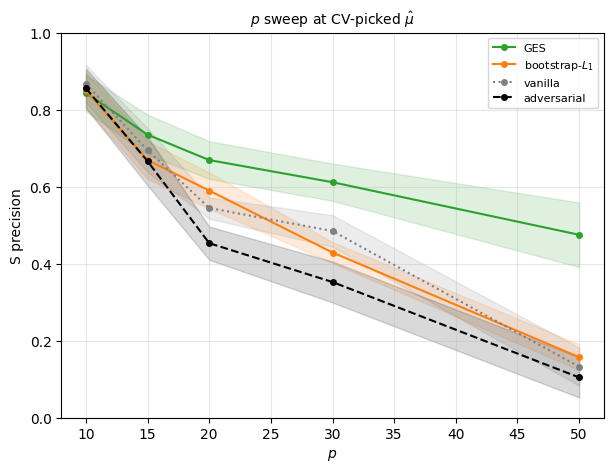

In [9]:
viz.plot_recovery_cv_vs_axis(p_cv, axis_col='p')

## Effect holds across target sparsity

$k^*$ sweep at $p=30, n=300, p_\mathrm{edge}=0.2$, $K = 2 k^*$, `S_precision`. GES$-$vanilla is +0.02 / +0.13 / +0.15 at $k^*\in\{3,5,7\}$; the mechanism holds across sparsities (`causal_precision` agrees: +0.07 / +0.12 / +0.07).

<Axes: title={'center': '$k^{*}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$k^{*}$', ylabel='S precision'>

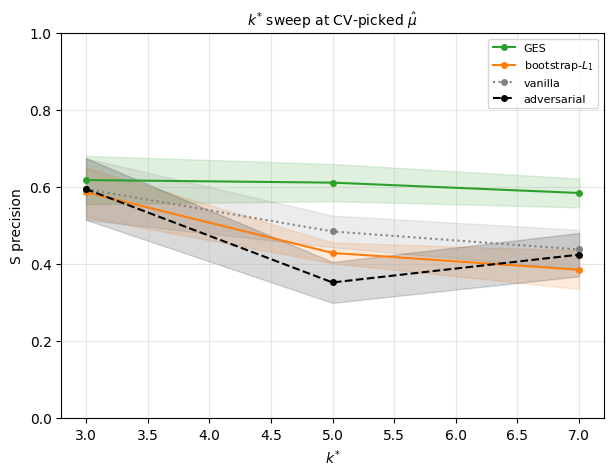

In [10]:
viz.plot_recovery_cv_vs_axis(k_cv, axis_col='k_star')

## Effect across noise scale (SNR robustness)

$\sigma_\mathrm{noise} \in \{0.5, 1.0, 2.0\}$ at the anchor $p=30, n=300, k^*=5, p_\mathrm{edge}=0.2$, `S_precision`. The motivating hypothesis was that the prior should help more at low SNR (high $\sigma$). The data are flat-to-peaked: GES$-$vanilla is +0.04 / +0.13 / +0.08 across $\sigma$, peaking at the default $\sigma=1.0$ rather than growing with noise. Present but not SNR-amplified in this range.

<Axes: title={'center': '$\\sigma_{\\mathrm{noise}}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$\\sigma_{\\mathrm{noise}}$', ylabel='S precision'>

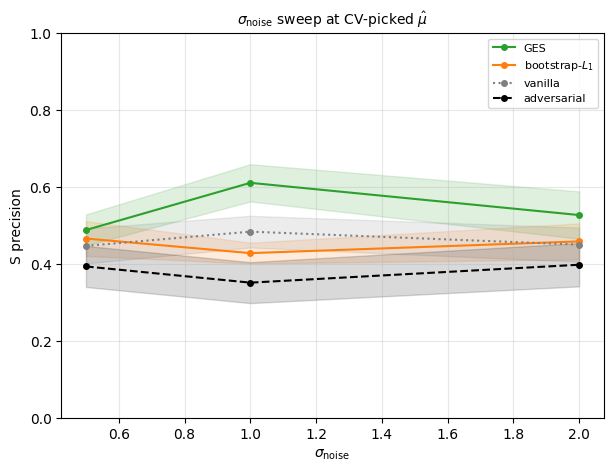

In [11]:
viz.plot_recovery_cv_vs_axis(noise_cv, axis_col='noise_scale')

## Soft prior tracks the best hard threshold

For each $q$ source, soft penalty at $\mu_\mathrm{rel}=1$ vs hard pre-selection at thresholds $t \in \{0.3, 0.5, 0.7\}$ vs $p_\mathrm{edge}$, `S_precision`. The best hard threshold shifts with $p_\mathrm{edge}$ (no single $t$ wins everywhere), so hard pre-selection needs per-regime tuning; the soft prior avoids it.

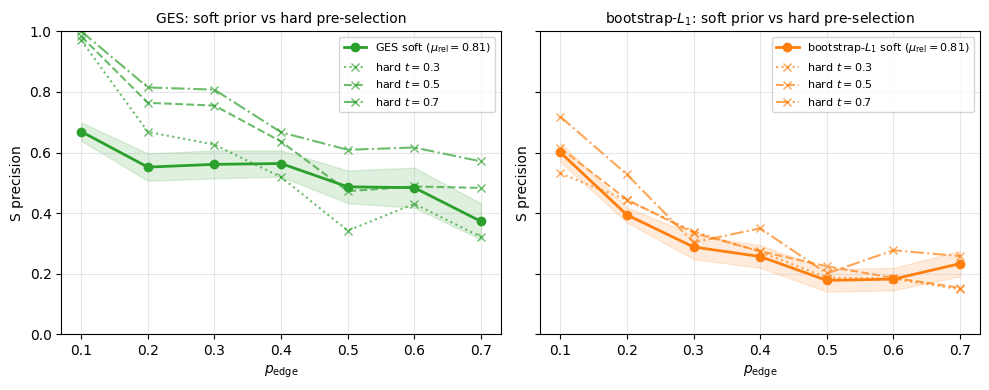

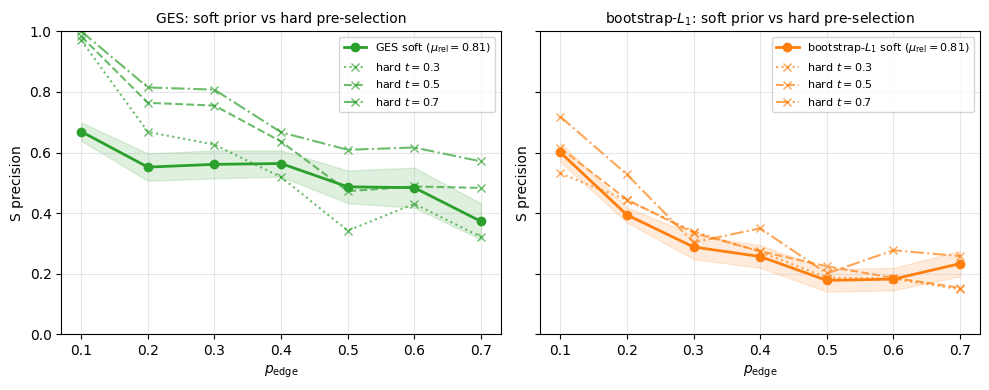

In [12]:
viz.plot_soft_vs_hard_facet(pe_sweep, q_sources=['ges', 'bootstrap_l1'], ncols=2)

## K-ablation: effect across cardinality budgets

Anchor cell $p=30, n=300, k^*=5, p_\mathrm{edge}=0.2$, 20 seeds. $K \in \{k^*, 1.5 k^*, 2 k^*, 3 k^*\}$. CV picks $\hat{\mu}$ per (cell, $K$, $q$ source) on log-loss; `S_precision` evaluated against $S^*$. Checks whether the benefit holds when the budget is tighter or looser than the headline $K = 2 k^*$.

<Axes: title={'center': '$K / k^{*}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$K / k^{*}$', ylabel='S precision'>

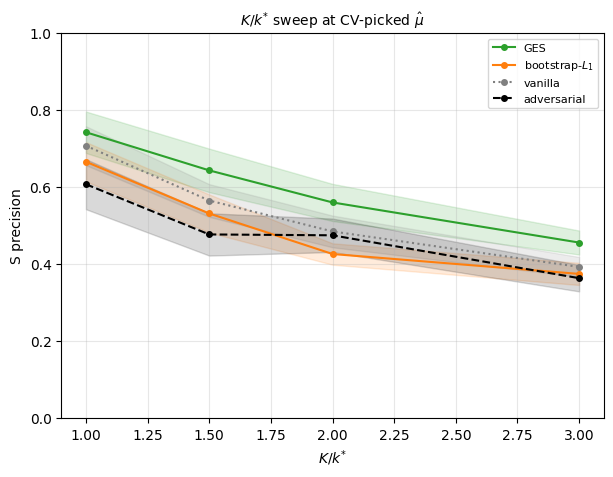

In [13]:
k_abl = load_recovery_csvs(ROOT / 'results/causal_prior/synthetic/recovery_p30_K_ablation')
k_abl = k_abl[~k_abl['q_source'].str.startswith('pc')]
k_abl = k_abl[k_abl['q_source'] != 'oracle']
viz.plot_recovery_cv_vs_axis(k_abl, axis_col='K_multiplier')

GES$-$vanilla (`S_precision`) is +0.04 at $K=k^*$, +0.08 at $1.5 k^*$, +0.08 at $2 k^*$, +0.06 at $3 k^*$. At the tight budget $K=k^*$ there is little headroom (FR already saturates on the strongest, mostly causal features); the effect appears once $K\geq 1.5 k^*$ frees spare slots and is roughly flat across the generous budgets. The headline $K = 2 k^*$ is representative, not cherry-picked. (`causal_precision` agrees the tight budget has no room: +0.00 at $K=k^*$, rising to +0.06–0.08 for $K\geq 1.5 k^*$.)

## CV-on-stability as an alternative criterion

CV-on-log_loss picks $\hat{\mu}$ to minimize held-out predictive loss; at high $p_\mathrm{edge}$ this can favor small $\hat{\mu}$ because confounders are predictive-but-spurious and log-loss happily uses them. CV-on-stability picks $\hat{\mu}$ to maximize mean pairwise Jaccard of selected supports across folds, which should reward features whose selection is invariant to data perturbation (causal features moreso than confounded ones).

Stability sweep on the $p_\mathrm{edge}$ axis only, same anchor cell shape as the headline.

In [14]:
cv_stab = load_recovery_csvs(ROOT / 'results/causal_prior/synthetic/recovery_p30_headline_cv_stability')
cv_stab = cv_stab[~cv_stab['q_source'].str.startswith('pc')]
cv_stab = cv_stab[cv_stab['q_source'] != 'oracle']
pe_cv_stab = cv_stab[cv_stab['noise_scale'] == 1.0].query('p == 30 and n == 300 and k_star == 5')

<Axes: title={'center': '$p_{\\mathrm{edge}}$ sweep at CV-picked $\\hat{\\mu}$'}, xlabel='$p_{\\mathrm{edge}}$', ylabel='S precision'>

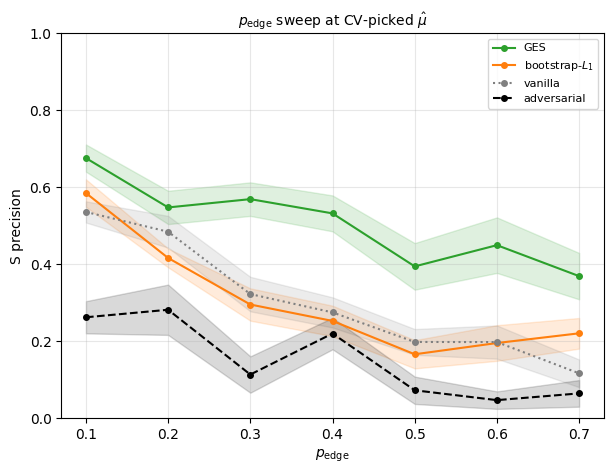

In [15]:
viz.plot_recovery_cv_vs_axis(pe_cv_stab, axis_col='p_edge')

<Axes: title={'center': 'CV-picked $\\mu$ vs $p_{\\mathrm{edge}}$'}, xlabel='$p_{\\mathrm{edge}}$', ylabel='$\\hat{\\mu}_{\\mathrm{rel}}$ (CV)'>

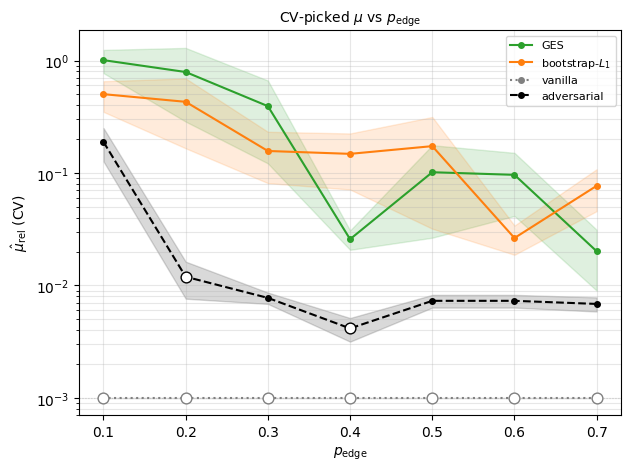

In [16]:
viz.plot_mu_star_vs_axis(pe_cv_stab, axis_col='p_edge')

Two effects stand out against the log-loss headline, in `S_precision`.

Stability CV pushes $\hat{\mu}$ up at low $p_\mathrm{edge}$ (GES median $\hat{\mu}_\mathrm{rel}=0.81$ at $p_\mathrm{edge}=0.1$, collapsing to ~0.01 by $p_\mathrm{edge}\geq 0.3$) and recovers a comparable GES advantage: GES$-$vanilla is +0.14 at $p_\mathrm{edge}=0.1$ and +0.20–0.25 across $p_\mathrm{edge}\geq 0.3$, on par with log-loss CV.

The cost: stability CV is not source-aware. Adversarial $q$ gets turned on against the wrong features and `S_precision` drops by **$-0.27$ at $p_\mathrm{edge}=0.1$** (negative across all $p_\mathrm{edge}$), whereas log-loss CV collapses adversarial $\hat{\mu}$ to 0 and stays at the vanilla floor. Log-loss CV is self-correcting against bad priors; stability CV measures only support agreement, which an adversarial $q$ can manufacture.

Practical takeaway: log-loss CV is the safer default; stability CV pays off only when $q$ is known informative. And under either criterion the GES benefit is genuine but modest; the $p=18$ TB regime (sparse but small) remains the open question for §6.3.